In [1]:
!pip install -U torch==1.10 torchvision==0.11 -f https://download.pytorch.org/whl/cu113/torch_stable.html 
!pip install cython pyyaml==5.1
!pip install -U 'git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI'
!gcc --version
!python --version 

Looking in links: https://download.pytorch.org/whl/cu113/torch_stable.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 GB 743.0 kB/s eta 0:00:000:0100:02m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 48.2 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: torch
    Found existing installation: torch 1.13.0
    Uninstalling torch-1.13.0:
      Successfully uninstalled torch-1.13.0
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.14.0
    Uninstalling torchvision-0.14.0:
      Successfully uninstalled torchvision-0.14.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 12.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyyaml: filename=PyYAML-5.1-cp37-cp37m-linux_x86_64.whl size=44090 sha256=65e28e51fd4914ddb492984087c03608d62ee20772ebd966bf2f0ca7906431fd
  Stored in directory: /root/.cache/pip/wheels/37/d0/7b/970c331404e286cba3221c59967d311ee0db0202407385fe30
Successfully built pyyaml
  At

In [2]:
!pip install detectron2==0.6 -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu113/torch1.10/index.html

Looking in links: https://dl.fbaipublicfiles.com/detectron2/wheels/cu113/torch1.10/index.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 56.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.3/403.3 kB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.0/131.0 kB 14.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 13.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61431 sha256=1b93caa72f2badab372888cb8150060a79267bf83d535472dbf0cd531e3f6203
  Stored in directory: /root/.cache/pip/wheels/12/a2/36/21b9bde5f8deeeb6312efe88ddde26a5

In [3]:
!pip install editdistance --upgrade packaging

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.6/282.6 kB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 23.0
    Uninstalling packaging-23.0:
      Successfully uninstalled packaging-23.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cudf 21.12.2 requires cupy-cuda115, which is not installed.
cudf 21.12.2 requires cupy-cuda115, which is not installed.
tensorflow 2.11.0 requires protobuf<3.20,>=3.9.2, but you have protobuf 3.20.3 which is incompatible.
tensorflow-transform 1.12.0 requires pyarrow<7,>=6, but you have pyarrow 5.0.0 which is incompatible.
tensorflow-serving-api 2.11.0 requires protobuf<3.20,>=3.9.2, but you have protobuf 3.20.3 which is incompatible.
pytorch-lightning 1.9.4 requires PyYAML>=5.4, but you have p

In [5]:
!pip install -q fvcore gdown

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch
import os
import cv2
import numpy as np
import json
from collections import defaultdict, OrderedDict
from pathlib import Path
from PIL import Image
import gdown
import sys
import random
import string
from utils.transforms import convert_box_format, check_and_refine_valid_box
from utils.visualize import overlay, draw_polygon
from tqdm import tqdm 
import time
from fvcore.nn import FlopCountAnalysis, parameter_count
from argparse import Namespace 
device = "cuda" if torch.cuda.is_available() else "cpu"
import warnings
import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings('ignore', category=DeprecationWarning)

if not hasattr(np, 'bool'):
    np.bool = bool


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)               # CPU
    torch.cuda.manual_seed(seed)          # GPU
    torch.cuda.manual_seed_all(seed)      # Multi-GPU (nếu có)

    # For deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [8]:
class SignboardText(Dataset):
    def __init__(self, image_data, annotation_data, transforms=None, TextInstance=None, Sample=None, 
                 augmentation=None, method=None):
        self.image_data = image_data

        self.image_list = os.listdir(image_data)
        self.annotation_lookup = self.read_json(annotation_data)
        self.transforms = transforms 
        self.TextInstance = TextInstance
        self.Sample = Sample
        self.method = method
        self.augmentation = augmentation

    def read_json(self, file): 
        with open(file, 'r') as file: 
            data = json.load(file)

        # Create mapping: id images and image_id annotations
        annotations_lookup = defaultdict(list)
        for info in data['annotations']:
            annotations_lookup[info['image_id']].append(info)

        return annotations_lookup

    def extract_info(self, info):
        labels = []
        for p in info:
            object = {}
            bbox = p['bbox']
            seg = p['segmentation']
            transcript = p['transcription']

            object['bbox'] = bbox
            object['segmentation'] = seg
            object['transcription'] = transcript

            labels.append(object)

        return labels

    def __len__(self):
        return len(self.image_list)
    
    def __getitem__(self, index):
        image_name = self.image_list[index]
        image_id = os.path.join(Path(self.image_data).name, image_name)
        image_path = os.path.join(self.image_data, image_name)
        info = self.annotation_lookup.get(image_id)
        if info is not None: labels = self.extract_info(info)
        else: 
            print(image_path)
            labels = None 

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_height, image_width = image.shape[:2]
        gt = {
            'file_name': image_id, 
            'image_size': image.shape[:2],
        }
        polygons, transcriptions = [], []
        if labels is not None: 
            for i, label in enumerate(labels): 
                segmentation = label['segmentation']
                transcription = label['transcription']
                bbox = label['bbox']
                new_bbox = check_and_refine_valid_box(bbox, image_width, image_height)
                if new_bbox is None: continue
                polygons.append(segmentation)
                transcriptions.append(transcription)
                # polygons.append(self.TextInstance(segmentation, 'c', transcription))

        if self.transforms is not None:
            if self.method == 'units':
                sample = self.Sample(image_size=image.shape[:2])
                image, _ = self.transforms(Image.fromarray(image), sample)

            if self.method in ['testr', 'deepsolo', 'dntext']:
                aug_input = self.transforms.StandardAugInput(image)
                aug_input.apply_augmentations(self.augmentation)
                image = aug_input.image
            
        if image.shape[-1] == 3: 
            image = np.ascontiguousarray(image.transpose(2, 0, 1)) # C, H, W

        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image)
            
        gt['image'] = image
        gt['polygons'] = torch.from_numpy(np.array([polygon for polygon in polygons],
                                                  dtype=np.int32))
        gt['transcriptions'] = [transcription for transcription in transcriptions]

        return gt

In [9]:
PRED_ICDAR = 'Prediction_ICDAR'
PRED_TOTAL = 'Prediction_TOTAL'

def create_folder(folder): 
    if not Path(folder).is_dir():
        Path(folder).mkdir(parents=True, exist_ok=True)

def save_output_txt(file_name, polygons, pred_transcriptions, confidences=None, boxes=None, contours=None): 
    sub_folder, file = Path(file_name).parent, Path(file_name).with_suffix('.txt').name
    pred_icdar_folder = os.path.join(PRED_ICDAR, sub_folder)
    pred_total_folder = os.path.join(PRED_TOTAL, sub_folder)

    create_folder(pred_icdar_folder)
    create_folder(pred_total_folder)

    pred_icdar_file = os.path.join(pred_icdar_folder, file)
    pred_total_file = os.path.join(pred_total_folder, file)
    if len(polygons) > 0: 
        if boxes is not None: 
            with open(pred_icdar_file, 'w') as f: 
                for box, transcription, conf in zip(boxes, pred_transcriptions, confidences): 
                    line = box.flatten()
                    f.write(','.join(map(str, line)) + f',{conf:.2f}' + f',{transcription}' + '\n')

        if contours is not None: 
            with open(pred_total_file, 'w') as f: 
                for contour, transcription, conf in zip(contours, pred_transcriptions, confidences): 
                    line = contour.flatten()
                    f.write(','.join(map(str, line)) + f',{conf:.2f}' + f',{transcription}' + '\n')

In [11]:
def get_state_dict(state_dict, idx): 
    new_state_dict = OrderedDict()
    for k, v in state_dict.items(): 
        new_k = k[idx:] 
        new_state_dict[new_k] = v

    return new_state_dict

def measure_fps(model, image, num_runs=100):    
    # Warm-up
    with torch.inference_mode():
        for _ in range(10):
            _ = model(image)
    
    # Measure FPS
    torch.cuda.synchronize()
    start = time.time()
    
    with torch.inference_mode():
        for _ in range(num_runs):
            _ = model(image)
            
    torch.cuda.synchronize()
    end = time.time()
    
    avg_time = (end - start) / num_runs
    fps = 1 / avg_time
    
    print(f"Average time per frame: {avg_time*1000:.2f} ms")
    
    return fps

def measure_flops(model, image): 
    flops = FlopCountAnalysis(model, image).total() / 1e9
    return flops

def measure_params(model): 
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
    non_trainable = sum(p.numel() for p in model.parameters() if not p.requires_grad) / 1e6
    total = trainable + non_trainable

    return total, trainable, non_trainable

In [12]:
def collate_fn(batch): 
    return {
        'file_name': [b['file_name'] for b in batch],
        'image_size': [b['image_size'] for b in batch],
        'list_images': [{'image': b['image']} for b in batch],
        'polygons': [b['polygons'] for b in batch],
        'transcriptions': [b['transcriptions'] for b in batch]
    }

def rescale_box(image, orig_size, boxes=None, contours=None):
    assert len(image.shape) == 4
    original_height, original_width = orig_size
    transformed_height, transformed_width = image.shape[2:] # B, C, H, W
    ratio = [original_width / transformed_width, original_height / transformed_height]

    if boxes is not None: 
        boxes = [np.round(box * ratio).astype(np.int32) for box in boxes] 
    if contours is not None: 
        contours = [np.round(contour * ratio).astype(np.int32) for contour in contours]

    return boxes, contours

### TESTR

In [13]:
!git clone https://github.com/mlpc-ucsd/TESTR.git
%cd /kaggle/working/TESTR
!python setup.py build develop

Cloning into 'TESTR'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 96 (delta 13), reused 9 (delta 9), pack-reused 52 (from 1)
Receiving objects: 100% (96/96), 229.96 KiB | 10.45 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/kaggle/working/TESTR
running build
running build_py
creating build
creating build/lib.linux-x86_64-3.7
creating build/lib.linux-x86_64-3.7/adet
copying adet/__init__.py -> build/lib.linux-x86_64-3.7/adet
creating build/lib.linux-x86_64-3.7/adet/layers
copying adet/layers/pos_encoding.py -> build/lib.linux-x86_64-3.7/adet/layers
copying adet/layers/deformable_transformer.py -> build/lib.linux-x86_64-3.7/adet/layers
copying adet/layers/ms_deform_attn.py -> build/lib.linux-x86_64-3.7/adet/layers
copying adet/layers/__init__.py -> build/lib.linux-x86_64-3.7/adet/layers
creating build/lib.linux-x86_64-3.7/adet/checkpoint
copying adet/checkpoint/adet_checkpoint.p

In [15]:
# Download pretrained model
!curl 'https://ucsdcloud-my.sharepoint.com/personal/xiz102_ucsd_edu/_layouts/15/download.aspx?SourceUrl=%2Fpersonal%2Fxiz102%5Fucsd%5Fedu%2FDocuments%2Fpublish%2Fcvpr22%5Ftestr%2Fweights%2Ficdar15%5Ftestr%5FR%5F50%5Fpolygon%2Epth' \
  -H 'User-Agent: Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:145.0) Gecko/20100101 Firefox/145.0' \
  -H 'Accept: text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8' \
  -H 'Accept-Language: en-US,en;q=0.5' \
  -H 'Accept-Encoding: gzip, deflate, br, zstd' \
  -H 'Referer: https://ucsdcloud-my.sharepoint.com/personal/xiz102_ucsd_edu/_layouts/15/onedrive.aspx?id=%2Fpersonal%2Fxiz102%5Fucsd%5Fedu%2FDocuments%2Fpublish%2Fcvpr22%5Ftestr%2Fweights%2Ficdar15%5Ftestr%5FR%5F50%5Fpolygon%2Epth&parent=%2Fpersonal%2Fxiz102%5Fucsd%5Fedu%2FDocuments%2Fpublish%2Fcvpr22%5Ftestr%2Fweights&ga=1' \
  -H 'Upgrade-Insecure-Requests: 1' \
  -H 'Sec-Fetch-Dest: iframe' \
  -H 'Sec-Fetch-Mode: navigate' \
  -H 'Sec-Fetch-Site: same-origin' \
  -H 'Connection: keep-alive' \
  -H 'Cookie: MicrosoftApplicationsTelemetryDeviceId=af2436b4-c6d1-4591-ad75-02323c6bb750; MSFPC=GUID=9fb9988b464e474a8295b39b61f9f95f&HASH=9fb9&LV=202509&V=4&LU=1756890731170; FedAuth=77u/PD94bWwgdmVyc2lvbj0iMS4wIiBlbmNvZGluZz0idXRmLTgiPz48U1A+VjE0LDBoLmZ8bWVtYmVyc2hpcHx1cm4lM2FzcG8lM2F0ZW5hbnRhbm9uI2FlN2ZjMDRjLTllMTItNDE1NC04YTdhLWM0MmZmNDE1ZWEyNywwIy5mfG1lbWJlcnNoaXB8dXJuJTNhc3BvJTNhdGVuYW50YW5vbiNhZTdmYzA0Yy05ZTEyLTQxNTQtOGE3YS1jNDJmZjQxNWVhMjcsMTM0MDg3OTkwMjEwMDAwMDAwLDAsMTM0MDg4ODUxMjE4NzA2OTI3LDAuMC4wLjAsMjU4LGFlN2ZjMDRjLTllMTItNDE1NC04YTdhLWM0MmZmNDE1ZWEyNywsLDViYzJkZGExLWUwNGEtMDAwMC0yMDBhLTZjMmFmN2Q4NDk3NCw1YmMyZGRhMS1lMDRhLTAwMDAtMjAwYS02YzJhZjdkODQ5NzQsSXoxN3JnK0VGVStzMXVjclcvWUR3ZywwLDAsMCwsLCwyNjUwNDY3NzQzOTk5OTk5OTk5LDAsLCwsLCwsMCwsMjAxMzAzLGpRbHFTX2d4SUlTWmxLenBXRDlLZV9XZTBTTSwsWFJQdVBqNFh5UExEVzN1MnBodmk4RlM2Q0NHTlBJRDN0c2krRGpKbGltdzg5ajhBLzBkRDQ4Z1kvVlFrQkZxaFd2ZWFaNFRMc2doZXBua3NKSDBITTJCalVIZXM1SksvdDh4NUhBMHhuRGZiT3BNTWd4cVdJUUxlMTF5SWxJTDRCZEFWVDhJV2hVVnhGUXMwMnFENktMK00rekdzY1ozQnBZbWJvWGNWRGI3WVg1UkhQSDNOYnVFekdXZm1wVGdCbWtRelRKMk41QlB4eVVRRWVhTnpmNzhEWDN5eWRPRFJlaWpuRG9vZld5YVl4YmlQS1ZyMC8xODdISk1rZlNFYnk2TUorWTdxRkpzd3lzMkdDSXhBQ1UzMk1XdDRpc2JwdUhBOWViNE8zSGRuc2p4WGNyTVpNOFNVaEJISy9waW9NZ0ZYc1JxNHJBbXZGWFhoejFBOGlBPT08L1NQPg==; FeatureOverrides_experiments=[]; ai_session=Z2aaHXPQnU0k5yn0WT9FqV|1764325124515|1764325124524; msal.cache.encryption=%7B%22id%22%3A%22019ac9f8-ea51-75cd-a71d-8633126fe998%22%2C%22key%22%3A%22l7wM2J4Wpsh-86wcMhLe3ltJw1M0g6ol3mQIenAQLt8%22%7D; SPA_RT=' \
  --output testr_icd15.pth

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  565M  100  565M    0     0  40.8M      0  0:00:13  0:00:13 --:--:-- 52.1M 0:00:15  0:00:11  0:00:04 40.4M


In [17]:
from adet.config import get_cfg
from adet.modeling.transformer_detector import TransformerDetector
from adet.data.detection_utils import build_augmentation
from detectron2.data import transforms 
from adet.evaluation.text_evaluation import TextEvaluator
from detectron2.data import MetadataCatalog
from detectron2.utils.visualizer import ColorMode

NULL_CHAR = u'口'
CTLABELS = [' ','!','"','#','$','%','&','\'','(',')','*','+',',','-','.','/','0','1','2','3','4','5','6','7','8','9',
            ':',';','<','=','>','?','@','A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T',
            'U','V','W','X','Y','Z','[','\\',']','^','_','`','a','b','c','d','e','f','g','h','i','j','k','l','m','n','o',
            'p','q','r','s','t','u','v','w','x','y','z','{','|','}','~']

def pnt_to_polygon(cfg, ctrl_pnt):
    if cfg.MODEL.TRANSFORMER.USE_POLYGON:
        return ctrl_pnt.reshape(-1, 2).tolist()
    else:
        u = np.linspace(0, 1, 20)
        ctrl_pnt = ctrl_pnt.reshape(2, 4, 2).transpose(0, 2, 1).reshape(4, 4)
        points = np.outer((1 - u) ** 3, ctrl_pnt[:, 0]) \
            + np.outer(3 * u * ((1 - u) ** 2), ctrl_pnt[:, 1]) \
            + np.outer(3 * (u ** 2) * (1 - u), ctrl_pnt[:, 2]) \
            + np.outer(u ** 3, ctrl_pnt[:, 3])
        
        # convert points to polygon
        points = np.concatenate((points[:, :2], points[:, 2:]), axis=0)
        return points.tolist()

def ctc_decode(cfg, rec):
    # ctc decoding
    last_char = False
    s = ''
    for c in rec:
        c = int(c)
        if c < cfg.MODEL.BATEXT.VOC_SIZE - 1:
            if last_char != c:
                if cfg.MODEL.BATEXT.VOC_SIZE == 96:
                    s += CTLABELS[c]
                    last_char = c
                else:
                    s += str(chr(CTLABELS[c]))
                    last_char = c
        elif c == cfg.MODEL.BATEXT.VOC_SIZE -1:
            s += u'口'
        else:
            last_char = False
    return s


def decode(cfg, rec):
    s = ''
    for c in rec:
        c = int(c)
        if c < cfg.MODEL.BATEXT.VOC_SIZE - 1:
            if cfg.MODEL.BATEXT.VOC_SIZE == 96:
                s += CTLABELS[c]
            else:
                s += str(chr(CTLABELS[c]))
        elif c == cfg.MODEL.BATEXT.VOC_SIZE -1:
            s += NULL_CHAR

    return s

def data_transfer_ICDAR(contours):
    cnts = list()
    for cont in contours:
        rect = cv2.minAreaRect(cont)
        if min(rect[1][0], rect[1][1]) <=8 :
            continue
        #rect=(rect[0],(rect[1][0]-3, rect[1][1]-3), rect[2])
        points = cv2.boxPoints(rect)
        points = np.int0(points)
        # print(points.shape)
        # points = np.reshape(points, (4, 2))
        cnts.append(points)
    return cnts

def inference(model, inputs, orig_size): 
    model.eval()
    with torch.inference_mode():
        outputs = model(inputs)
        boxes, transcriptions, confidences = [], [], []
        for output, image, size in zip(outputs, inputs, orig_size): 
            points = output['instances'].polygons.cpu().numpy() 
            recs = output['instances'].recs.cpu().numpy()
            conf = output['instances'].scores.cpu().numpy() 
            polygons = np.array([pnt_to_polygon(cfg, ctrl_pnt=point) for point in points])
            polygons, _ = rescale_box(image['image'].unsqueeze(dim=0), size, boxes=polygons)
            quads = data_transfer_ICDAR(polygons)
            text_recs = [decode(cfg, rec) for rec in recs]
        
            boxes.append(quads)
            transcriptions.append(text_recs)
            confidences.append(conf)

    return boxes, transcriptions, confidences

In [26]:
cfg = get_cfg()
cfg.merge_from_file('/kaggle/working/TESTR/configs/TESTR/ICDAR15/TESTR_R_50_Polygon.yaml')
augmentation = build_augmentation(cfg, is_train=False)
checkpoint = torch.load('/kaggle/working/TESTR/testr_icd15.pth', map_location=device)
state_dict = checkpoint['model']
cfg.MODEL.DEVICE = device
testr_model = TransformerDetector(cfg)
# Load weight
testr_model.load_state_dict(state_dict, strict=True)
testr_model = testr_model.to(device)
testr_model.test_score_threshold = 0.3

In [19]:
english_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                           annotation_data='/kaggle/input/signboardtext/annotations.json',
                           transforms=transforms,
                           augmentation=augmentation,
                          method='testr')
vietsignboard_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                               annotation_data='/kaggle/input/signboardtext/annotations.json',
                               transforms=transforms,
                                 augmentation=augmentation,
                                method='testr')
vin_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin',
                        annotation_data='/kaggle/input/signboardtext/annotations.json',
                        transforms=transforms,
                       augmentation=augmentation,
                      method='testr')
vietsignboard_line = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json',
                                   transforms=transforms,
                                   augmentation=augmentation,
                                   method='testr')

In [20]:
viet_dataloader = DataLoader(dataset=vietsignboard_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
english_dataloader = DataLoader(dataset=english_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
vin_dataloader = DataLoader(dataset=vin_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
viet_dataloaderline = DataLoader(dataset=vietsignboard_line, batch_size=2, shuffle=False, collate_fn=collate_fn)

In [ ]:
set_seed(42)
for data in tqdm(viet_dataloader): 
    file_name, list_images = data['file_name'], data['list_images']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']

    qboxes, pred_transcriptions, confidences = inference(testr_model, list_images, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

In [32]:
set_seed(42)
for data in tqdm(english_dataloader): 
    file_name, list_images = data['file_name'], data['list_images']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']

    qboxes, pred_transcriptions, confidences = inference(testr_model, list_images, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

100%|██████████| 207/207 [03:15<00:00,  1.06it/s]


In [ ]:
set_seed(42)
for data in tqdm(vin_dataloader): 
    file_name, list_images = data['file_name'], data['list_images']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']

    qboxes, pred_transcriptions, confidences = inference(testr_model, list_images, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

In [ ]:
set_seed(42)
for data in tqdm(viet_dataloaderline): 
    file_name, list_images = data['file_name'], data['list_images']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']

    qboxes, pred_transcriptions, confidences = inference(testr_model, list_images, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

In [31]:
set_seed(seed=42) 
image = dict(image=torch.rand((3, 640, 640)).to(device))
fps = measure_fps(testr_model, [image])
total_params, trainable_params, non_trainable_params = measure_params(testr_model)
print('---------TESTR---------')
print(f'FPS: {fps:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

Average time per frame: 90.04 ms
---------TESTR---------
FPS: 11.11
Total Params: 49.48
Trainable Params: 49.26
Non Trainable Params: 0.22


In [ ]:
!zip -r prediction_icdar.zip /kaggle/working/TESTR/Prediction_ICDAR

In [28]:
image = cv2.imread('/kaggle/input/signboardtext/images/train/vietsignboard/levansy-86.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
aug_input = transforms.StandardAugInput(image)
aug_input.apply_augmentations(augmentation)
img = aug_input.image
data = dict(image=torch.as_tensor(np.ascontiguousarray(img.transpose(2, 0, 1))))

testr_model.eval()
with torch.inference_mode():
    outputs = testr_model([data])

points = outputs[0]['instances'].polygons.cpu().numpy()
recs = outputs[0]['instances'].recs.cpu().numpy()
polygons = np.array([pnt_to_polygon(cfg, ctrl_pnt=point) for point in points])
polygons, _ = rescale_box(data['image'].unsqueeze(dim=0), image.shape[:2], boxes=polygons)
quads = data_transfer_ICDAR(polygons)

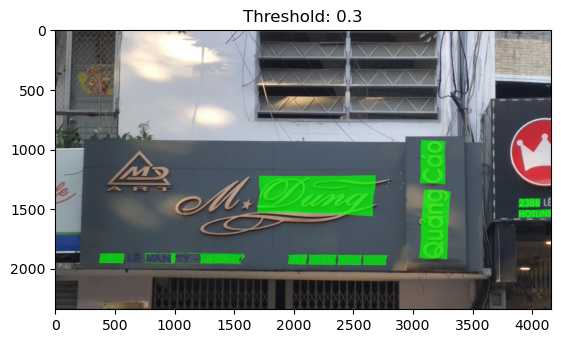

In [29]:
mask = np.zeros(image.shape[:2], np.uint8)
fill_mask = cv2.fillPoly(mask, np.array(polygons), color=1)
prediction = overlay(image, fill_mask, color=(0, 255, 0), alpha=0.7)
plt.imshow(prediction)
plt.title(f'Threshold: {testr_model.test_score_threshold}')
plt.show()

### DeepSolo

In [ ]:
!git clone https://github.com/ViTAE-Transformer/DeepSolo.git
%cd /kaggle/working/DeepSolo/DeepSolo
!python setup.py build develop

In [ ]:
!curl 'https://my.microsoftpersonalcontent.com/personal/e534267b85818129/_layouts/15/download.aspx?UniqueId=85818129-267b-2034-80e5-e86300000000&Translate=false&tempauth=v1e.eyJzaXRlaWQiOiIwNTdkZGVkNC01MDEzLTRmOGMtYWE3OC1hMWQxOTFkYzkwMmMiLCJhdWQiOiIwMDAwMDAwMy0wMDAwLTBmZjEtY2UwMC0wMDAwMDAwMDAwMDAvbXkubWljcm9zb2Z0cGVyc29uYWxjb250ZW50LmNvbUA5MTg4MDQwZC02YzY3LTRjNWItYjExMi0zNmEzMDRiNjZkYWQiLCJleHAiOiIxNzY0MTc2OTE5In0.lGw3iXraN0E07dVcohDc-uhjdMueZ5AcKIGPZfDrR7QxumKfrf9E2xvOYhBBTAKSNjHLUEwV2aEMCEWHsrHLvW46ym748GkEee832lLQkPzn0ivLzoJs0kcFuK7kT_Czxm1l3YFcymOxjaAW11SCnmd-Af2rxbjUmsfSgbBWtPXehfIdWJfyMCypR2hW2ExJmlIhS3M83CDV1hUpP8zrfvhF8HBCKcsEmG6ZMSM6CG9wLwORgxqPy7M_Ove7jUlsdlDOqfay5HwXXmtz3mbzWi94-AI7_0WMUPggEWtgi8-vMY5lFc03HgvaUwba-MlQJAngvB7nWMCCmMz0ldwPjWQtQe5AhZ1YqdvugaSP1WngkmB2nPyjui7sfzqNMgaDDP7B4rRWDA56sOblLHVwjsiKpxasO50WSEf5jyEk3DNzOPdWWcmtTQtIauCLGXROOtmDZjMzExdP0GOJk30EXhTibjK-JTUaqgmz_wLM1-NzONgSXZi6hRqZw-Lisfvn1ugD1UaZVE1nCZsiHcwTdg.cihMihc-pFsg2Mz9Khg6rsPbPGtoZTzdRZeEtnTr3ts&ApiVersion=2.0' \
  -H 'User-Agent: Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:145.0) Gecko/20100101 Firefox/145.0' \
  -H 'Accept: text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8' \
  -H 'Accept-Language: en-US,en;q=0.5' \
  -H 'Accept-Encoding: gzip, deflate, br, zstd' \
  -H 'Alt-Used: my.microsoftpersonalcontent.com' \
  -H 'Connection: keep-alive' \
  -H 'Referer: https://onedrive.live.com/' \
  -H 'Cookie: MicrosoftApplicationsTelemetryDeviceId=ba432ab8-31ed-4920-be3f-55630b42cb8b; MSFPC=GUID=1a3945e370eb417ebb8dd96b72135d37&HASH=1a39&LV=202506&V=4&LU=1750859448535' \
  -H 'Upgrade-Insecure-Requests: 1' \
  -H 'Sec-Fetch-Dest: iframe' \
  -H 'Sec-Fetch-Mode: navigate' \
  -H 'Sec-Fetch-Site: cross-site' \
  -H 'Priority: u=4' \
  -H 'TE: trailers' \
 --output deepsolo.pth

In [ ]:
from detectron2.data import transforms
from detectron2.data.transforms import Augmentation, PadTransform
import logging


class Pad(Augmentation):
    def __init__(self, divisible_size = 32):
        super().__init__()
        self._init(locals())

    def get_transform(self, img):
        ori_h, ori_w = img.shape[:2]  # h, w
        if ori_h % 32 == 0:
            pad_h = 0
        else:
            pad_h = 32 - ori_h % 32
        if ori_w % 32 == 0:
            pad_w = 0
        else:
            pad_w = 32 - ori_w % 32
        # pad_h, pad_w = 32 - ori_h % 32, 32 - ori_w % 32
        return PadTransform(
            0, 0, pad_w, pad_h, pad_value=0
        )
        
def build_augmentation(cfg, is_train): 
    """
    With option to don't use hflip

    Returns:
        list[Augmentation]
    """
    if is_train:
        min_size = cfg.INPUT.MIN_SIZE_TRAIN
        max_size = cfg.INPUT.MAX_SIZE_TRAIN
        sample_style = cfg.INPUT.MIN_SIZE_TRAIN_SAMPLING
    else:
        min_size = cfg.INPUT.MIN_SIZE_TEST
        max_size = cfg.INPUT.MAX_SIZE_TEST
        sample_style = "choice"
    if sample_style == "range":
        assert (
            len(min_size) == 2
        ), "more than 2 ({}) min_size(s) are provided for ranges".format(len(min_size))

    logger = logging.getLogger(__name__)

    augmentation = []
    augmentation.append(transforms.ResizeShortestEdge(min_size, max_size, sample_style))  # 限制长宽比

    if is_train:
        augmentation.append(transforms.RandomContrast(0.3, 1.7))  # T.RandomContrast：随机调整图像对比度。
        augmentation.append(transforms.RandomBrightness(0.3, 1.7))  # 亮度
        augmentation.append(transforms.RandomLighting(random.random() + 0.5))  # 光照
        augmentation.append(transforms.RandomSaturation(0.3, 1.7))  # 饱和度
        logger.info("Augmentations used in training: " + str(augmentation))
    if cfg.MODEL.BACKBONE.NAME == "build_vitaev2_backbone":
        augmentation.append(Pad(divisible_size=32))  # 用于填充图像使其宽高可被 32 整除
    return augmentation

In [ ]:
from adet.config import get_cfg
from adet.modeling.text_spotter import TransformerPureDetector
from adet.utils.visualizer import TextVisualizer
from detectron2.data import MetadataCatalog
from detectron2.utils.visualizer import ColorMode

def pnt_to_polygon(pnt):
    polygon = np.hsplit(pnt, 2)
    polygon = np.vstack([polygon[0], polygon[1][::-1]])
    return polygon.tolist()

def ctc_decode(cfg, rec):
    if cfg.MODEL.TRANSFORMER.VOC_SIZE == 37:
        CTLABELS = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's',
                             't', 'u', 'v', 'w', 'x', 'y', 'z', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

    elif cfg.MODEL.TRANSFORMER.VOC_SIZE == 96:
        CTLABELS = [' ','!','"','#','$','%','&','\'','(',')','*','+',',','-','.','/',
                             '0','1','2','3','4','5','6','7','8','9',':',';','<','=','>','?','@',
                             'A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U','V',
                             'W','X','Y','Z','[','\\',']','^','_','`','a','b','c','d','e','f','g','h','i','j','k','l',
                             'm','n','o','p','q','r','s','t','u','v','w','x','y','z','{','|','}','~']

    else:
        raise NotImplementedError

    last_char = '###'
    s = ''
    for c in rec:
        c = int(c)
        if c < cfg.MODEL.TRANSFORMER.VOC_SIZE - 1:
            if last_char != c:
                if cfg.MODEL.TRANSFORMER.VOC_SIZE == 37 or cfg.MODEL.TRANSFORMER.VOC_SIZE == 96:
                    s += CTLABELS[c]
                    last_char = c
                else:
                    s += str(chr(CTLABELS[c]))
                    last_char = c
        else:
            last_char = '###'

    return s

def data_transfer_ICDAR(contours):
    cnts = list()
    for cont in contours:
        rect = cv2.minAreaRect(cont)
        if min(rect[1][0], rect[1][1]) <=8 :
            continue
        #rect=(rect[0],(rect[1][0]-3, rect[1][1]-3), rect[2])
        points = cv2.boxPoints(rect)
        points = np.int0(points)
        # print(points.shape)
        # points = np.reshape(points, (4, 2))
        cnts.append(points)
    return cnts

def inference(model, inputs, orig_size): 
    model.eval()
    with torch.inference_mode():
        outputs = model(inputs)
        boxes, transcriptions, confidences = [], [], []
        for output, image, size in zip(outputs, inputs, orig_size): 
            points = output['instances'].bd.cpu().numpy() 
            recs = output['instances'].recs.cpu().numpy()
            conf = output['instances'].scores.cpu().numpy() 
            polygons = np.array([pnt_to_polygon(pnt=point) for point in points])
            polygons, _ = rescale_box(image['image'].unsqueeze(dim=0), size, boxes=polygons)
            quads = data_transfer_ICDAR(polygons)
            text_recs = [ctc_decode(cfg, rec) for rec in recs]
        
            boxes.append(quads)
            transcriptions.append(text_recs)
            confidences.append(conf)

    return boxes, transcriptions, confidences

In [ ]:
cfg = get_cfg()
cfg.merge_from_file('/kaggle/working/DeepSolo/DeepSolo/configs/R_50/IC15/finetune_150k_tt_mlt_13_15_textocr.yaml')
augmentation = build_augmentation(cfg, is_train=False)
checkpoint = torch.load('/kaggle/working/DeepSolo/DeepSolo/deepsolo.pth', map_location=device)
state_dict = checkpoint['model']
cfg.MODEL.DEVICE = device
deepsolo = TransformerPureDetector(cfg)
# Load weight
deepsolo.load_state_dict(state_dict, strict=True)
deepsolo = deepsolo.to(device)
deepsolo.test_score_threshold = 0.3

In [ ]:
english_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                           annotation_data='/kaggle/input/signboardtext/annotations.json',
                           transforms=transforms,
                           augmentation=augmentation,
                          method='deepsolo')
vietsignboard_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                               annotation_data='/kaggle/input/signboardtext/annotations.json',
                               transforms=transforms,
                                 augmentation=augmentation,
                                method='deepsolo')
vin_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin',
                        annotation_data='/kaggle/input/signboardtext/annotations.json',
                        transforms=transforms,
                       augmentation=augmentation,
                      method='deepsolo')
vietsignboard_line = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json',
                                   transforms=transforms,
                                   augmentation=augmentation,
                                   method='deepsolo')

In [ ]:
viet_dataloader = DataLoader(dataset=vietsignboard_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
english_dataloader = DataLoader(dataset=english_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
vin_dataloader = DataLoader(dataset=vin_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
viet_dataloaderline = DataLoader(dataset=vietsignboard_line, batch_size=2, shuffle=False, collate_fn=collate_fn)

In [ ]:
set_seed(42)
for data in tqdm(viet_dataloader): 
    file_name, list_images = data['file_name'], data['list_images']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']

    qboxes, pred_transcriptions, confidences = inference(deepsolo, list_images, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

In [ ]:
set_seed(42)
for data in tqdm(english_dataloader): 
    file_name, list_images = data['file_name'], data['list_images']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']

    qboxes, pred_transcriptions, confidences = inference(deepsolo, list_images, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

In [ ]:
set_seed(42)
for data in tqdm(vin_dataloader): 
    file_name, list_images = data['file_name'], data['list_images']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']

    qboxes, pred_transcriptions, confidences = inference(deepsolo, list_images, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

In [ ]:
set_seed(42)
for data in tqdm(viet_dataloaderline): 
    file_name, list_images = data['file_name'], data['list_images']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']

    qboxes, pred_transcriptions, confidences = inference(deepsolo, list_images, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

In [ ]:
set_seed(seed=42) 
image = dict(image=torch.rand((3, 640, 640)).to(device))
fps = measure_fps(deepsolo, [image])
total_params, trainable_params, non_trainable_params = measure_params(deepsolo)
print('---------DeepSolo---------')
print(f'FPS: {fps:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

In [ ]:
!zip -r prediction_icdar.zip /kaggle/working/DeepSolo/DeepSolo/Prediction_ICDAR

In [ ]:
image = cv2.imread('/kaggle/input/signboardtext/images/train/vietsignboard/levansy-86.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
aug_input = transforms.StandardAugInput(image)
aug_input.apply_augmentations(augmentation)
img = aug_input.image
data = dict(image=torch.as_tensor(np.ascontiguousarray(img.transpose(2, 0, 1))))

deepsolo.eval()
with torch.inference_mode():
    outputs = deepsolo([data])

points = outputs[0]['instances'].ctrl_points.cpu().numpy()

In [ ]:
points = outputs[0]['instances'].bd.cpu().numpy()
recs = outputs[0]['instances'].recs.cpu().numpy()
polygons = np.array([pnt_to_polygon(pnt=point) for point in points])
quads, _ = rescale_box(data['image'].unsqueeze(dim=0), image.shape[:2], boxes=polygons)
text_recs = [ctc_decode(cfg, rec) for rec in recs]

In [ ]:
mask = np.zeros(image.shape[:2], np.uint8)
fill_mask = cv2.fillPoly(mask, np.array(quads).astype(np.int32), color=1)
prediction = overlay(image, fill_mask, color=(0, 255, 0), alpha=0.7)
plt.imshow(prediction)
plt.title(f'Threshold: {deepsolo.test_score_threshold}')
plt.show()

### DNTextSPotter

In [13]:
!git clone https://github.com/yyyyyxie/DNTextSpotter.git
%cd /kaggle/working/DNTextSpotter
!python setup.py build develop

Cloning into 'DNTextSpotter'...
remote: Enumerating objects: 1124, done.
remote: Counting objects: 100% (1124/1124), done.
remote: Compressing objects: 100% (876/876), done.
remote: Total 1124 (delta 243), reused 1098 (delta 222), pack-reused 0 (from 0)
Receiving objects: 100% (1124/1124), 1.48 MiB | 18.75 MiB/s, done.
Resolving deltas: 100% (243/243), done.
/kaggle/working/DNTextSpotter
running build
running build_py
creating build
creating build/lib.linux-x86_64-3.7
creating build/lib.linux-x86_64-3.7/adet
copying adet/__init__.py -> build/lib.linux-x86_64-3.7/adet
creating build/lib.linux-x86_64-3.7/adet/modeling
copying adet/modeling/__init__.py -> build/lib.linux-x86_64-3.7/adet/modeling
copying adet/modeling/text_spotter.py -> build/lib.linux-x86_64-3.7/adet/modeling
creating build/lib.linux-x86_64-3.7/adet/layers
copying adet/layers/deformable_transformer.py -> build/lib.linux-x86_64-3.7/adet/layers
copying adet/layers/pos_encoding.py -> build/lib.linux-x86_64-3.7/adet/layers
co

In [14]:
file_id = '1xwzd0qxIBLIM2rqx_S6_nBSiX-UiIrLa'
url_model = f'https://drive.google.com/uc?id={file_id}'

# Download pretrained model
gdown.download(url_model, 'dntext.pth', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1xwzd0qxIBLIM2rqx_S6_nBSiX-UiIrLa
From (redirected): https://drive.google.com/uc?id=1xwzd0qxIBLIM2rqx_S6_nBSiX-UiIrLa&confirm=t&uuid=d3f903c6-c4e7-4432-afb0-9f610f4743e2
To: /kaggle/working/DNTextSpotter/dntext.pth
100%|██████████| 512M/512M [00:04<00:00, 114MB/s]  


'dntext.pth'

In [15]:
from detectron2.data import transforms
from detectron2.data.transforms import Augmentation, PadTransform
import logging


class Pad(Augmentation):
    def __init__(self, divisible_size = 32):
        super().__init__()
        self._init(locals())

    def get_transform(self, img):
        ori_h, ori_w = img.shape[:2]  # h, w
        if ori_h % 32 == 0:
            pad_h = 0
        else:
            pad_h = 32 - ori_h % 32
        if ori_w % 32 == 0:
            pad_w = 0
        else:
            pad_w = 32 - ori_w % 32
        # pad_h, pad_w = 32 - ori_h % 32, 32 - ori_w % 32
        return PadTransform(
            0, 0, pad_w, pad_h, pad_value=0
        )
        
def build_augmentation(cfg, is_train): 
    """
    With option to don't use hflip

    Returns:
        list[Augmentation]
    """
    if is_train:
        min_size = cfg.INPUT.MIN_SIZE_TRAIN
        max_size = cfg.INPUT.MAX_SIZE_TRAIN
        sample_style = cfg.INPUT.MIN_SIZE_TRAIN_SAMPLING
    else:
        min_size = cfg.INPUT.MIN_SIZE_TEST
        max_size = cfg.INPUT.MAX_SIZE_TEST
        sample_style = "choice"
    if sample_style == "range":
        assert (
            len(min_size) == 2
        ), "more than 2 ({}) min_size(s) are provided for ranges".format(len(min_size))

    logger = logging.getLogger(__name__)

    augmentation = []
    augmentation.append(transforms.ResizeShortestEdge(min_size, max_size, sample_style))  # 限制长宽比

    if is_train:
        augmentation.append(transforms.RandomContrast(0.3, 1.7))  # T.RandomContrast：随机调整图像对比度。
        augmentation.append(transforms.RandomBrightness(0.3, 1.7))  # 亮度
        augmentation.append(transforms.RandomLighting(random.random() + 0.5))  # 光照
        augmentation.append(transforms.RandomSaturation(0.3, 1.7))  # 饱和度
        logger.info("Augmentations used in training: " + str(augmentation))
    if cfg.MODEL.BACKBONE.NAME == "build_vitaev2_backbone":
        augmentation.append(Pad(divisible_size=32))  # 用于填充图像使其宽高可被 32 整除
    return augmentation

In [16]:
from adet.config import get_cfg
from adet.modeling.text_spotter import TransformerPureDetector
from adet.utils.visualizer import TextVisualizer
from detectron2.data import MetadataCatalog
from detectron2.utils.visualizer import ColorMode

def pnt_to_polygon(pnt):
    polygon = np.hsplit(pnt, 2)
    polygon = np.vstack([polygon[0], polygon[1][::-1]])
    return polygon.tolist()

def ctc_decode(cfg, rec):
    if cfg.MODEL.TRANSFORMER.VOC_SIZE == 37:
        CTLABELS = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's',
                             't', 'u', 'v', 'w', 'x', 'y', 'z', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

    elif cfg.MODEL.TRANSFORMER.VOC_SIZE == 96:
        CTLABELS = [' ','!','"','#','$','%','&','\'','(',')','*','+',',','-','.','/',
                             '0','1','2','3','4','5','6','7','8','9',':',';','<','=','>','?','@',
                             'A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U','V',
                             'W','X','Y','Z','[','\\',']','^','_','`','a','b','c','d','e','f','g','h','i','j','k','l',
                             'm','n','o','p','q','r','s','t','u','v','w','x','y','z','{','|','}','~']

    else:
        raise NotImplementedError

    last_char = '###'
    s = ''
    for c in rec:
        c = int(c)
        if c < cfg.MODEL.TRANSFORMER.VOC_SIZE - 1:
            if last_char != c:
                if cfg.MODEL.TRANSFORMER.VOC_SIZE == 37 or cfg.MODEL.TRANSFORMER.VOC_SIZE == 96:
                    s += CTLABELS[c]
                    last_char = c
                else:
                    s += str(chr(CTLABELS[c]))
                    last_char = c
        else:
            last_char = '###'

    return s

def data_transfer_ICDAR(contours):
    cnts = list()
    for cont in contours:
        rect = cv2.minAreaRect(cont)
        if min(rect[1][0], rect[1][1]) <=8 :
            continue
        #rect=(rect[0],(rect[1][0]-3, rect[1][1]-3), rect[2])
        points = cv2.boxPoints(rect)
        points = np.int0(points)
        # print(points.shape)
        # points = np.reshape(points, (4, 2))
        cnts.append(points)
    return cnts

def inference(model, inputs, orig_size): 
    model.eval()
    with torch.inference_mode():
        outputs = model(inputs)
        boxes, transcriptions, confidences = [], [], []
        for output, image, size in zip(outputs, inputs, orig_size): 
            points = output['instances'].bd.cpu().numpy() 
            recs = output['instances'].recs.cpu().numpy()
            conf = output['instances'].scores.cpu().numpy() 
            polygons = np.array([pnt_to_polygon(pnt=point) for point in points])
            polygons, _ = rescale_box(image['image'].unsqueeze(dim=0), size, boxes=polygons)
            quads = data_transfer_ICDAR(polygons)
            text_recs = [ctc_decode(cfg, rec) for rec in recs]
        
            boxes.append(quads)
            transcriptions.append(text_recs)
            confidences.append(conf)

    return boxes, transcriptions, confidences

In [17]:
cfg = get_cfg()
cfg.merge_from_file('/kaggle/working/DNTextSpotter/configs/R_50/IC15/finetune_150k_tt_mlt_13_15_textocr.yaml')
augmentation = build_augmentation(cfg, is_train=False)
checkpoint = torch.load('/kaggle/working/DNTextSpotter/dntext.pth', map_location=device)
state_dict = checkpoint['model']
cfg.MODEL.DEVICE = device
dntext_model = TransformerPureDetector(cfg)
# Load weight
dntext_model.load_state_dict(state_dict, strict=True)
dntext_model = dntext_model.to(device)
dntext_model.test_score_threshold = 0.3

In [18]:
image = cv2.imread('/kaggle/input/signboardtext/images/train/vietsignboard/levansy-86.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
aug_input = transforms.StandardAugInput(image)
aug_input.apply_augmentations(augmentation)
img = aug_input.image
data = dict(image=torch.as_tensor(np.ascontiguousarray(img.transpose(2, 0, 1))))

dntext_model.eval()
with torch.inference_mode():
    outputs = dntext_model([data])

points = outputs[0]['instances'].ctrl_points.cpu().numpy()

/opt/conda/lib/python3.7/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [19]:
english_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                           annotation_data='/kaggle/input/signboardtext/annotations.json',
                           transforms=transforms,
                           augmentation=augmentation,
                          method='dntext')
vietsignboard_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                               annotation_data='/kaggle/input/signboardtext/annotations.json',
                               transforms=transforms,
                                 augmentation=augmentation,
                                method='dntext')
vin_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin',
                        annotation_data='/kaggle/input/signboardtext/annotations.json',
                        transforms=transforms,
                       augmentation=augmentation,
                      method='dntext')
vietsignboard_line = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json',
                                   transforms=transforms,
                                   augmentation=augmentation,
                                   method='dntext')

In [20]:
viet_dataloader = DataLoader(dataset=vietsignboard_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
english_dataloader = DataLoader(dataset=english_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
vin_dataloader = DataLoader(dataset=vin_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
viet_dataloaderline = DataLoader(dataset=vietsignboard_line, batch_size=2, shuffle=False, collate_fn=collate_fn)

In [21]:
set_seed(42)
for data in tqdm(viet_dataloader): 
    file_name, list_images = data['file_name'], data['list_images']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']

    qboxes, pred_transcriptions, confidences = inference(dntext_model, list_images, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

 30%|██▉       | 179/597 [02:43<06:14,  1.12it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-11.jpg


 40%|███▉      | 237/597 [03:38<05:36,  1.07it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg


 42%|████▏     | 248/597 [03:47<05:25,  1.07it/s]

...

 50%|████▉     | 298/597 [04:37<04:57,  1.00it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg


 52%|█████▏    | 311/597 [04:49<04:02,  1.18it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg


100%|██████████| 597/597 [09:20<00:00,  1.07it/s]


In [ ]:
set_seed(42)
for data in tqdm(english_dataloader): 
    file_name, list_images = data['file_name'], data['list_images']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']

    qboxes, pred_transcriptions, confidences = inference(dntext_model, list_images, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

In [24]:
set_seed(42)
for data in tqdm(vin_dataloader): 
    file_name, list_images = data['file_name'], data['list_images']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']

    qboxes, pred_transcriptions, confidences = inference(dntext_model, list_images, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

100%|██████████| 258/258 [04:03<00:00,  1.06it/s]


In [ ]:
set_seed(42)
for data in tqdm(viet_dataloaderline): 
    file_name, list_images = data['file_name'], data['list_images']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']

    qboxes, pred_transcriptions, confidences = inference(dntext_model, list_images, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

In [ ]:
!zip -r prediction_icdar.zip /kaggle/working/DNTextSpotter/Prediction_ICDAR

In [ ]:
set_seed(seed=42) 
image = dict(image=torch.rand((3, 640, 640)).to(device))
fps = measure_fps(dntext_model, [image])
total_params, trainable_params, non_trainable_params = measure_params(dntext_model)
print('---------DNTextSpotter---------')
print(f'FPS: {fps:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

In [ ]:
points = outputs[0]['instances'].bd.cpu().numpy()
recs = outputs[0]['instances'].recs.cpu().numpy()
polygons = np.array([pnt_to_polygon(pnt=point) for point in points])
quads, _ = rescale_box(data['image'].unsqueeze(dim=0), image.shape[:2], boxes=polygons)
text_recs = [ctc_decode(cfg, rec) for rec in recs]

In [ ]:
mask = np.zeros(image.shape[:2], np.uint8)
fill_mask = cv2.fillPoly(mask, np.array(quads).astype(np.int32), color=1)
prediction = overlay(image, fill_mask, color=(0, 255, 0), alpha=0.7)
plt.imshow(prediction)
plt.title(f'Threshold: {dntext_model.test_score_threshold}')
plt.show()